In [1]:
# "Customer Churn Prediction — Multi-Algorithm Classification Showdown" 

# ============================================================
# STEP 2 — DATASET LOADING & EXPLORATORY DATA ANALYSIS
# ============================================================

import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from imblearn.over_sampling import SMOTE

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
# print("Dataset Shape:", df)

print("Dataset Shape:", df.shape)
print("\nFirst 10 Rows:")
display(df.head(10))

print("\nDataset Info:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe(include="all").T)


Dataset Shape: (7043, 21)

First 10 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:

# 2.1 — TotalCharges cleaning and class balance

print("TotalCharges dtype BEFORE:", df["TotalCharges"].dtype)

# Blank/whitespace values become NaN, then numeric conversion
df["TotalCharges"] = df["TotalCharges"].replace(r"^\s*$", np.nan, regex=True)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing TotalCharges:", df["TotalCharges"].isna().sum())

# Fill using median as required
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print("TotalCharges dtype AFTER:", df["TotalCharges"].dtype)

print("\nChurn Counts:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
display((df["Churn"].value_counts(normalize=True) * 100).round(2))

print("\nClass imbalance ratio:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2).to_dict())


TotalCharges dtype BEFORE: object
Missing TotalCharges: 11
TotalCharges dtype AFTER: float64

Churn Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:


Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


Class imbalance ratio:
{'No': 73.46, 'Yes': 26.54}


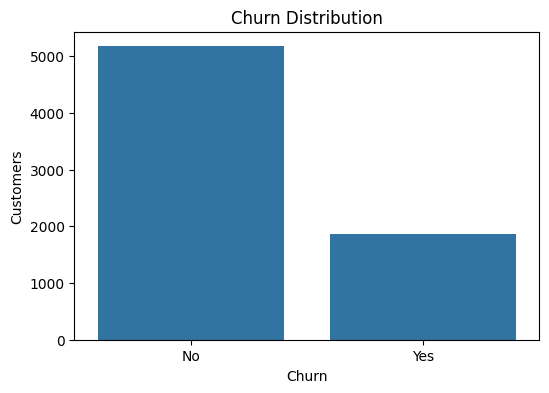

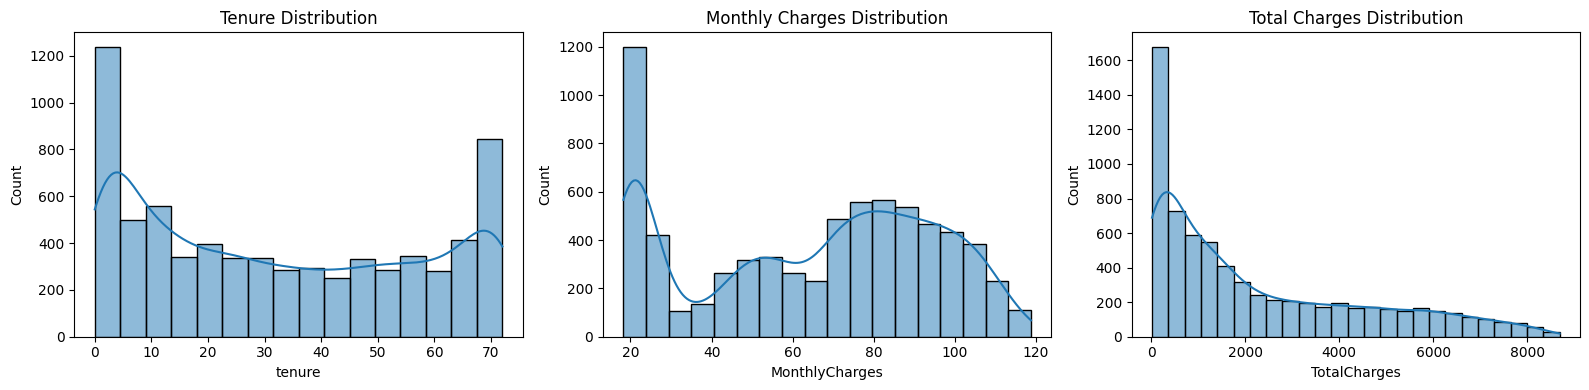

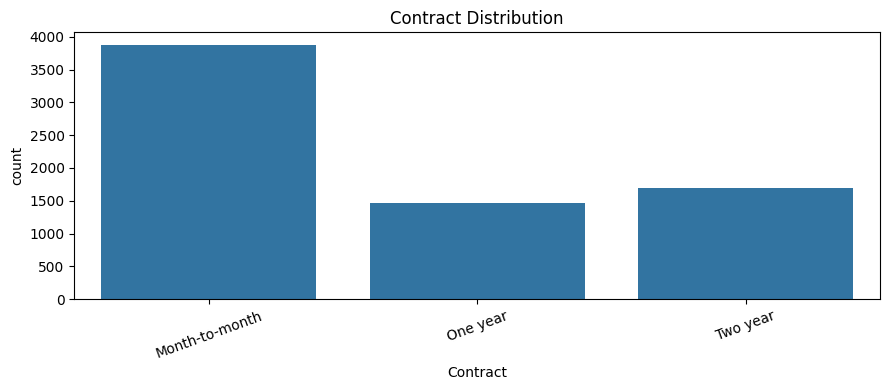

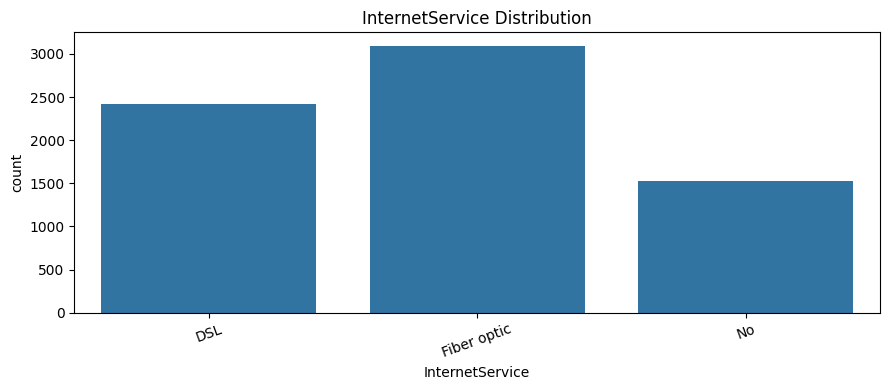

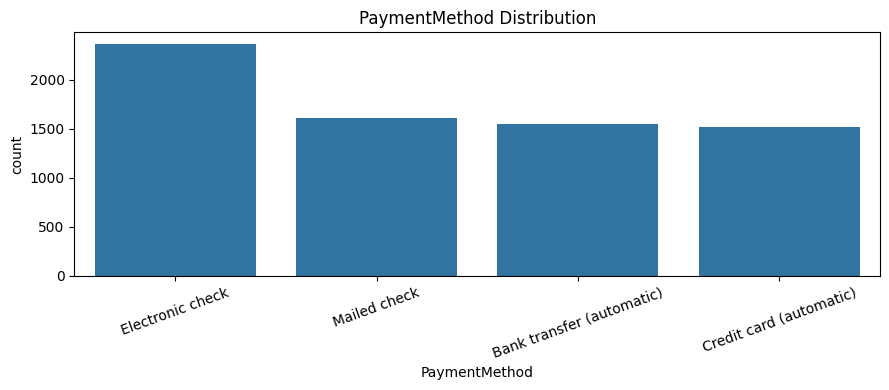

In [3]:

# 2.2 — Univariate Analysis

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customers")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df["tenure"], kde=True, ax=axes[0])
axes[0].set_title("Tenure Distribution")

sns.histplot(df["MonthlyCharges"], kde=True, ax=axes[1])
axes[1].set_title("Monthly Charges Distribution")

sns.histplot(df["TotalCharges"], kde=True, ax=axes[2])
axes[2].set_title("Total Charges Distribution")

plt.tight_layout()
plt.show()

for col in ["Contract", "InternetService", "PaymentMethod"]:
    plt.figure(figsize=(9, 4))
    sns.countplot(data=df, x=col)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


Churn Rate by Contract (%):


Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64

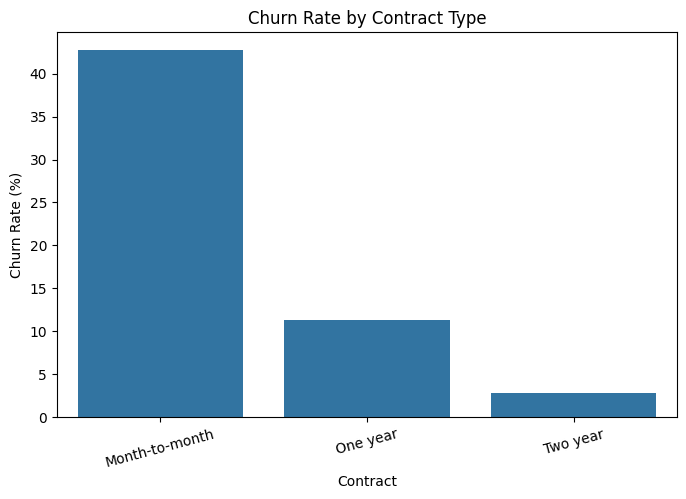

Churn Rate by Tenure Bucket (%):


TenureBucket
0-12     47.44
13-24    28.71
25-48    20.39
49-72     9.51
Name: Churn, dtype: float64

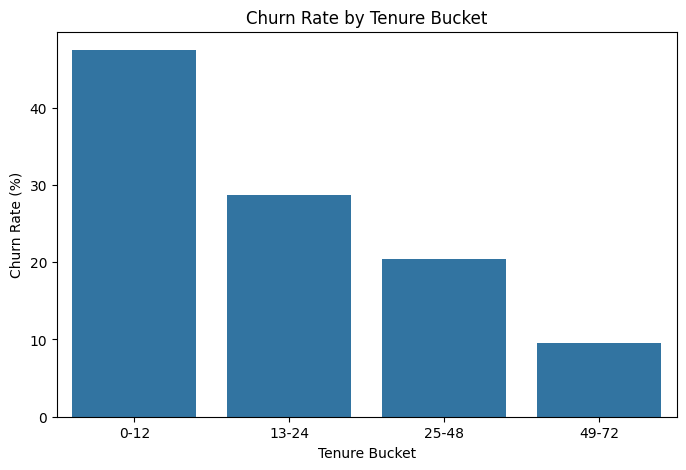

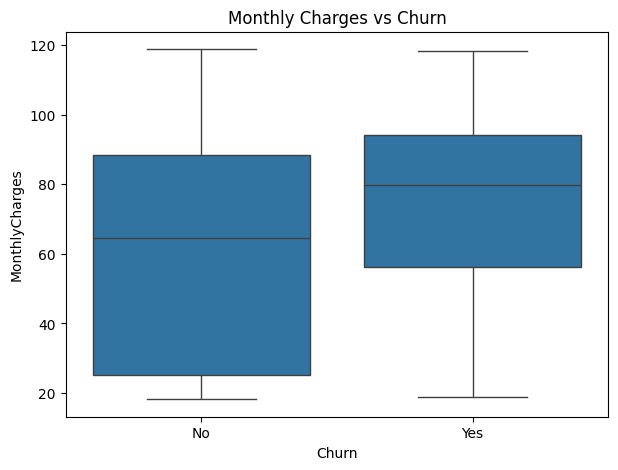

Average MonthlyCharges by Churn:


Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64

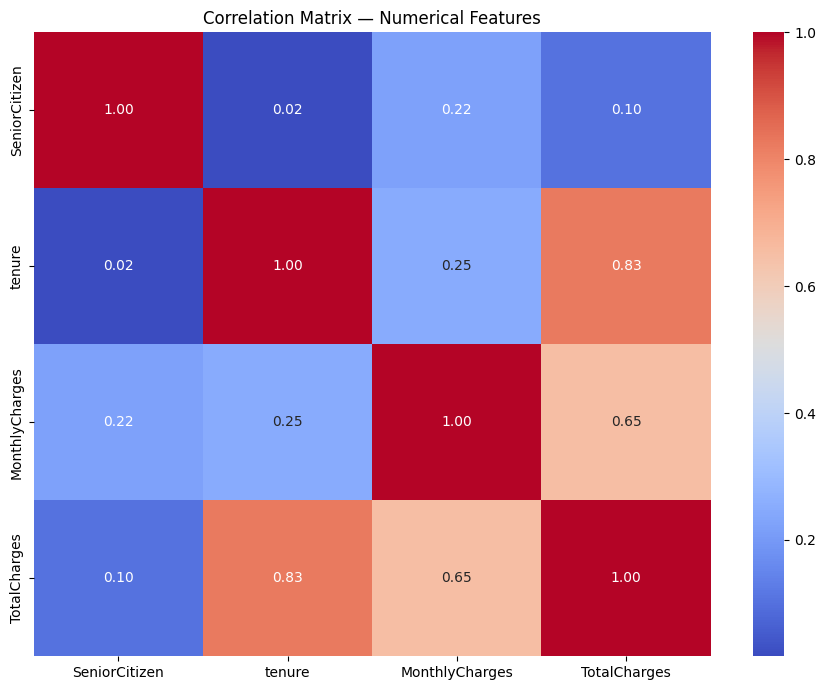

In [4]:

# 2.3 — Bivariate Analysis

# Churn rate by Contract
contract_rate = df.groupby("Contract")["Churn"].apply(
    lambda s: (s == "Yes").mean() * 100
)
print("Churn Rate by Contract (%):")
display(contract_rate.sort_values(ascending=False).round(2))

plt.figure(figsize=(8, 5))
sns.barplot(x=contract_rate.index, y=contract_rate.values)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract")
plt.xticks(rotation=15)
plt.show()

# Required tenure buckets: 0–12, 13–24, 25–48, 49–72
df["TenureBucket"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

tenure_rate = df.groupby("TenureBucket", observed=False)["Churn"].apply(
    lambda s: (s == "Yes").mean() * 100
)
print("Churn Rate by Tenure Bucket (%):")
display(tenure_rate.round(2))

plt.figure(figsize=(8, 5))
sns.barplot(x=tenure_rate.index, y=tenure_rate.values)
plt.title("Churn Rate by Tenure Bucket")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Tenure Bucket")
plt.show()

# MonthlyCharges vs Churn
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()

print("Average MonthlyCharges by Churn:")
display(df.groupby("Churn")["MonthlyCharges"].mean().round(2))

# Numeric correlation heatmap
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(9, 7))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix — Numerical Features")
plt.tight_layout()
plt.show()


# Step 3 — Data Preprocessing & Feature Engineering


In [5]:

# 3.1 — Drop & Clean

# Work on a fresh copy so Step 2 remains available for EDA.
data = df.copy()

# Drop unique ID — no predictive value
data = data.drop(columns=["customerID"], errors="ignore")

# TotalCharges was cleaned in Step 2; fill defensively again
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data["TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].median())

print("Remaining TotalCharges NaN:", data["TotalCharges"].isna().sum())


Remaining TotalCharges NaN: 0


In [6]:

# 3.2 — Feature Engineering

# Required ordinal tenure groups:
# New = 0–12, Mid = 13–36, Senior = 37–60, Loyal = 61+
data["tenure_group"] = pd.cut(
    data["tenure"],
    bins=[-1, 12, 36, 60, np.inf],
    labels=["New", "Mid", "Senior", "Loyal"]
)

# Required 6 add-on services
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

service_data = data[service_cols].replace({
    "Yes": 1,
    "No": 0,
    "No internet service": 0,
    "No phone service": 0
})

data["num_services"] = service_data.sum(axis=1)

# AutoPay = 1 for automatic payment methods
data["AutoPay"] = (
    data["PaymentMethod"]
    .str.contains("automatic", case=False, na=False)
    .astype(int)
)

print(data[["tenure", "tenure_group", "num_services", "AutoPay"]].head())


   tenure tenure_group  num_services  AutoPay
0       1          New             1        0
1      34          Mid             2        0
2       2          New             2        0
3      45       Senior             3        1
4       2          New             0        0


C:\Users\pmana\AppData\Local\Temp\ipykernel_11316\4045785208.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  service_data = data[service_cols].replace({


In [7]:

# 3.3 — Encoding

# Target
data["Churn"] = data["Churn"].map({"No": 0, "Yes": 1}).astype(int)

# Binary columns
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]

for col in binary_cols:
    data[col] = data[col].map({"Yes": 1, "No": 0}).fillna(0).astype(int)

# Gender
data["gender"] = data["gender"].map({"Female": 0, "Male": 1}).fillna(0).astype(int)

# MultipleLines
data["MultipleLines"] = data["MultipleLines"].map({
    "Yes": 1,
    "No": 0,
    "No phone service": 0
}).fillna(0).astype(int)

# One-hot encoding
data = pd.get_dummies(
    data,
    columns=["InternetService", "Contract", "PaymentMethod"],
    drop_first=True,
    dtype=int
)

# Label/ordinal encoding for tenure_group
data["tenure_group"] = data["tenure_group"].map({
    "New": 0,
    "Mid": 1,
    "Senior": 2,
    "Loyal": 3
}).fillna(0).astype(int)

# Drop original service columns after num_services is created
data = data.drop(columns=service_cols, errors="ignore")

# Drop EDA-only tenure bucket
data = data.drop(columns=["TenureBucket"], errors="ignore")

print("Encoded shape:", data.shape)
print("Object columns:", data.select_dtypes(include="object").columns.tolist())


Encoded shape: (7043, 21)
Object columns: []


In [9]:

# 3.4 — Final X/y, numeric safety, scaling

X = data.drop(columns=["Churn"])
y = data["Churn"].astype(int)

# Keep feature names ONLY after all engineering/encoding is complete.
feature_names = X.columns.tolist()

# Force numeric values
X = X.apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan)

# Median imputation on the complete prepared feature matrix
X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)
print("NaN:", X.isna().sum().sum())
print("Inf:", np.isinf(X.to_numpy()).sum())
print("\nFinal feature count:", len(feature_names))
print("\nFinal features:")
print(feature_names)

# Required scaling columns
scale_cols = ["tenure", "MonthlyCharges", "TotalCharges", "num_services"]

# Train-test split FIRST
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scale selected continuous features using training data only
scaler = StandardScaler()

X_train_df = X_train_df.copy()
X_test_df = X_test_df.copy()

X_train_df[scale_cols] = scaler.fit_transform(X_train_df[scale_cols])
X_test_df[scale_cols] = scaler.transform(X_test_df[scale_cols])

# Keep DataFrames for readable feature names
X_train = X_train_df
X_test = X_test_df

print("\nTrain/Test shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


Final X shape: (7043, 20)
Final y shape: (7043,)
NaN: 0
Inf: 0

Final feature count: 20

Final features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'tenure_group', 'num_services', 'AutoPay', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Train/Test shapes:
X_train: (5634, 20)
X_test : (1409, 20)
y_train: (5634,)
y_test : (1409,)


In [10]:

# 3.5 — Class imbalance + SMOTE ONLY on training data

print("Training class counts BEFORE SMOTE:")
print(y_train.value_counts().sort_index())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# SMOTE returns arrays/dataframes depending on input; make DataFrame for safety
X_train_smote = pd.DataFrame(
    X_train_smote,
    columns=feature_names
)
y_train_smote = pd.Series(
    y_train_smote,
    name="Churn"
)

print("\nTraining class counts AFTER SMOTE:")
print(y_train_smote.value_counts().sort_index())

print("\nBefore SMOTE:", X_train.shape)
print("After SMOTE :", X_train_smote.shape)
print("NaN after SMOTE:", X_train_smote.isna().sum().sum())
print("Inf after SMOTE:", np.isinf(X_train_smote.to_numpy()).sum())


Training class counts BEFORE SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64

Training class counts AFTER SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64

Before SMOTE: (5634, 20)
After SMOTE : (8278, 20)
NaN after SMOTE: 0
Inf after SMOTE: 0


# Step 4 — KNN & Naive Bayes

In [11]:

# 4.1 — KNN Baseline

def print_metrics(y_true, y_pred, y_prob, model_name):
    print(f"\n{model_name}")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 4))
    print("Recall   :", round(recall_score(y_true, y_pred, zero_division=0), 4))
    print("F1       :", round(f1_score(y_true, y_pred, zero_division=0), 4))
    print("AUC-ROC  :", round(roc_auc_score(y_true, y_prob), 4))

knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train_smote, y_train_smote)

pred_knn_base = knn_baseline.predict(X_test)
prob_knn_base = knn_baseline.predict_proba(X_test)[:, 1]

print_metrics(y_test, pred_knn_base, prob_knn_base, "KNN Baseline (k=5)")



KNN Baseline (k=5)
Accuracy : 0.7111
Precision: 0.4707
Recall   : 0.7086
F1       : 0.5656
AUC-ROC  : 0.7744


K values: [1, 3, 5, 7, 9, 11, 15]
Validation F1: [0.5181, 0.559, 0.5664, 0.573, 0.571, 0.5789, 0.5846]
Best K: 15
Best Validation F1: 0.5846


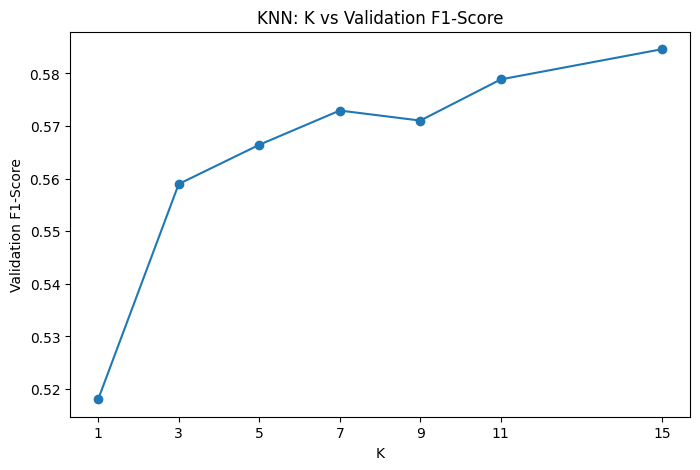

In [12]:

# KNN k tuning — use a validation split, NOT the final test set

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

# Apply SMOTE only to the inner training portion
X_tr_smote, y_tr_smote = SMOTE(
    random_state=42
).fit_resample(X_tr, y_tr)

k_values = [1, 3, 5, 7, 9, 11, 15]
knn_val_f1 = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_tr_smote, y_tr_smote)
    pred_val = model.predict(X_val)
    knn_val_f1.append(
        f1_score(y_val, pred_val, zero_division=0)
    )

best_k = k_values[int(np.argmax(knn_val_f1))]

print("K values:", k_values)
print("Validation F1:", [round(v, 4) for v in knn_val_f1])
print("Best K:", best_k)
print("Best Validation F1:", round(max(knn_val_f1), 4))

plt.figure(figsize=(8, 5))
plt.plot(k_values, knn_val_f1, marker="o")
plt.xlabel("K")
plt.ylabel("Validation F1-Score")
plt.title("KNN: K vs Validation F1-Score")
plt.xticks(k_values)
plt.show()



Final KNN (k=15)
Accuracy : 0.7182
Precision: 0.4817
Recall   : 0.8075
F1       : 0.6034
AUC-ROC  : 0.8158


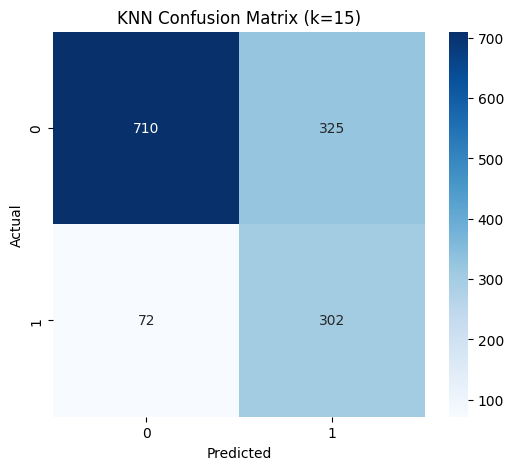

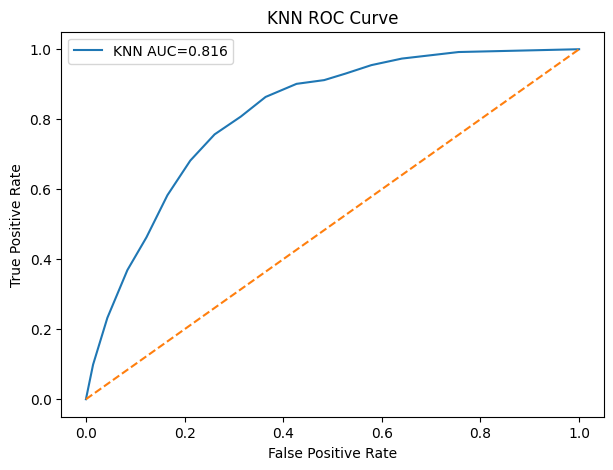

In [13]:

# Final KNN using optimal K — final test evaluated only here

best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_smote, y_train_smote)

pred_knn = best_knn.predict(X_test)
prob_knn = best_knn.predict_proba(X_test)[:, 1]

print_metrics(y_test, pred_knn, prob_knn, f"Final KNN (k={best_k})")

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, pred_knn),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title(f"KNN Confusion Matrix (k={best_k})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fpr_knn, tpr_knn, _ = roc_curve(y_test, prob_knn)
plt.figure(figsize=(7, 5))
plt.plot(fpr_knn, tpr_knn, label=f"KNN AUC={roc_auc_score(y_test, prob_knn):.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.legend()
plt.show()



Gaussian Naive Bayes
Accuracy : 0.7239
Precision: 0.4876
Recall   : 0.7914
F1       : 0.6035
AUC-ROC  : 0.8165

Learned class_prior_:
[0.5 0.5]

Original training churn rate:
0.2653532126375577

Test churn rate:
0.2654364797728886


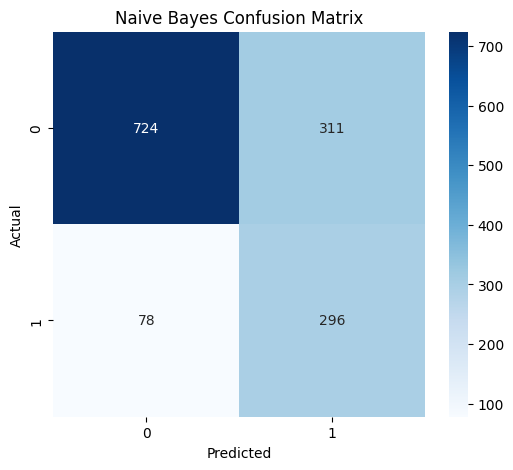

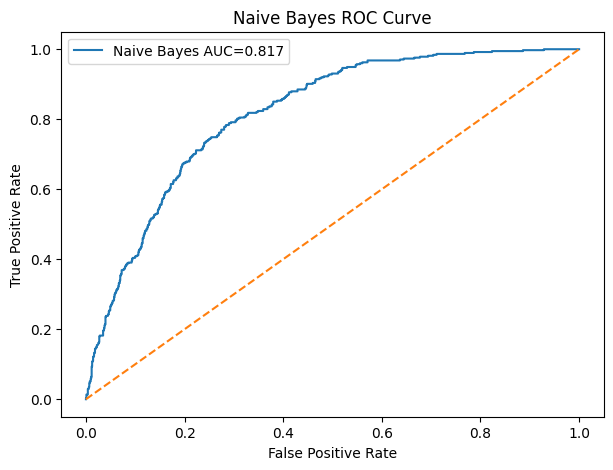


Naive Bayes assumption:
1. The features are assumed to be conditionally independent given the class.
2. In this dataset, some variables such as tenure and TotalCharges are related,
   so the independence assumption is not perfectly true.


In [14]:

# 4.2 — Gaussian Naive Bayes

nb = GaussianNB()
nb.fit(X_train_smote, y_train_smote)

pred_nb = nb.predict(X_test)
prob_nb = nb.predict_proba(X_test)[:, 1]

print_metrics(y_test, pred_nb, prob_nb, "Gaussian Naive Bayes")

print("\nLearned class_prior_:")
print(nb.class_prior_)

print("\nOriginal training churn rate:")
print(y_train.mean())

print("\nTest churn rate:")
print(y_test.mean())

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, pred_nb),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fpr_nb, tpr_nb, _ = roc_curve(y_test, prob_nb)
plt.figure(figsize=(7, 5))
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes AUC={roc_auc_score(y_test, prob_nb):.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Naive Bayes ROC Curve")
plt.legend()
plt.show()

print("\nNaive Bayes assumption:")
print("1. The features are assumed to be conditionally independent given the class.")
print("2. In this dataset, some variables such as tenure and TotalCharges are related,")
print("   so the independence assumption is not perfectly true.")


# Step 5 — SVM & Decision Tree


SVM Baseline (C=1)
Accuracy : 0.7445
Precision: 0.5125
Recall   : 0.7701
F1       : 0.6154
AUC-ROC  : 0.8222


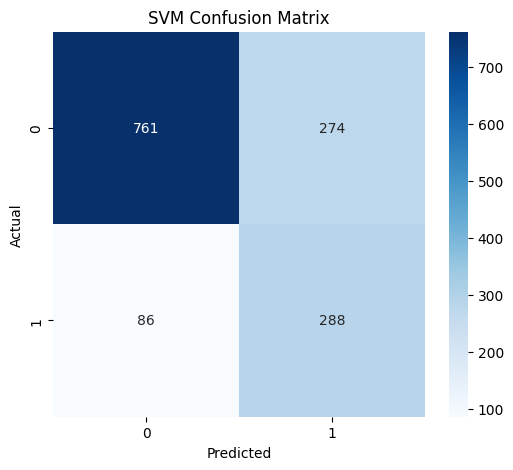

In [15]:

# 5.1 — SVM Baseline

svm_baseline = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    probability=True,
    random_state=42
)

svm_baseline.fit(X_train_smote, y_train_smote)

pred_svm_base = svm_baseline.predict(X_test)
prob_svm_base = svm_baseline.predict_proba(X_test)[:, 1]

print_metrics(y_test, pred_svm_base, prob_svm_base, "SVM Baseline (C=1)")

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, pred_svm_base),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


C values: [0.1, 1, 10, 100]
CV F1: [np.float64(0.7768), np.float64(0.7896), np.float64(0.8065), np.float64(0.8142)]
Best C: 100


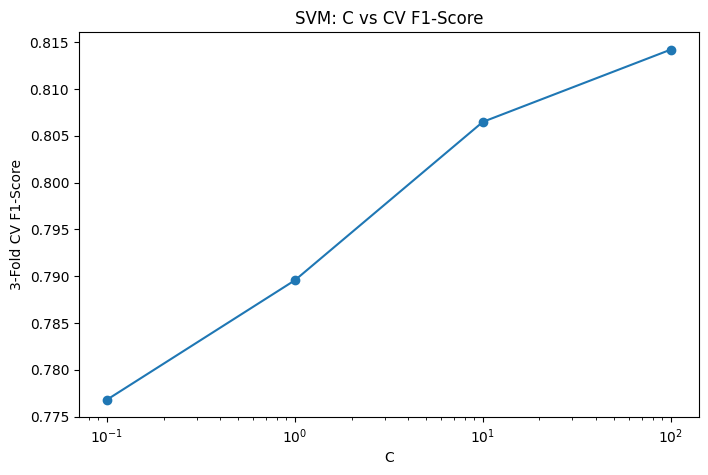

In [16]:

# SVM C tuning — 3-fold CV on training data only

C_values = [0.1, 1, 10, 100]
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

svm_cv_f1 = []

for c in C_values:
    model = SVC(
        kernel="rbf",
        C=c,
        gamma="scale",
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=cv,
        scoring="f1"
    )
    svm_cv_f1.append(scores.mean())

best_C = C_values[int(np.argmax(svm_cv_f1))]

print("C values:", C_values)
print("CV F1:", [round(v, 4) for v in svm_cv_f1])
print("Best C:", best_C)

plt.figure(figsize=(8, 5))
plt.plot(C_values, svm_cv_f1, marker="o")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("3-Fold CV F1-Score")
plt.title("SVM: C vs CV F1-Score")
plt.show()



Final SVM (C=100)
Accuracy : 0.7275
Precision: 0.4908
Recall   : 0.7139
F1       : 0.5817
AUC-ROC  : 0.7886


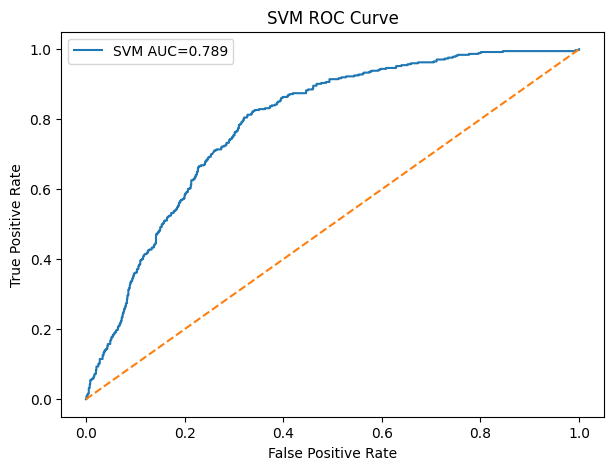


Business Tradeoff:
SVM can give strong predictive performance, but it is less interpretable.
For retention teams, higher performance can be valuable, while a simpler model
such as a Decision Tree may be easier to explain to business stakeholders.


In [17]:

# Final SVM

best_svm = SVC(
    kernel="rbf",
    C=best_C,
    gamma="scale",
    probability=True,
    random_state=42
)

best_svm.fit(X_train_smote, y_train_smote)

pred_svm = best_svm.predict(X_test)
prob_svm = best_svm.predict_proba(X_test)[:, 1]

print_metrics(y_test, pred_svm, prob_svm, f"Final SVM (C={best_C})")

fpr_svm, tpr_svm, _ = roc_curve(y_test, prob_svm)

plt.figure(figsize=(7, 5))
plt.plot(fpr_svm, tpr_svm, label=f"SVM AUC={roc_auc_score(y_test, prob_svm):.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.show()

print("\nBusiness Tradeoff:")
print("SVM can give strong predictive performance, but it is less interpretable.")
print("For retention teams, higher performance can be valuable, while a simpler model")
print("such as a Decision Tree may be easier to explain to business stakeholders.")



Decision Tree Baseline (max_depth=5)
Accuracy : 0.7303
Precision: 0.4953
Recall   : 0.8449
F1       : 0.6245
AUC-ROC  : 0.8245


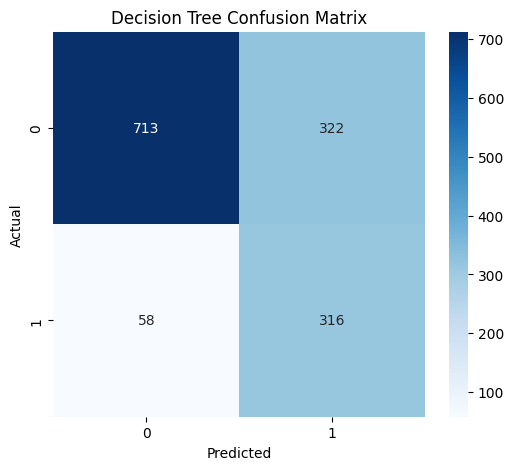

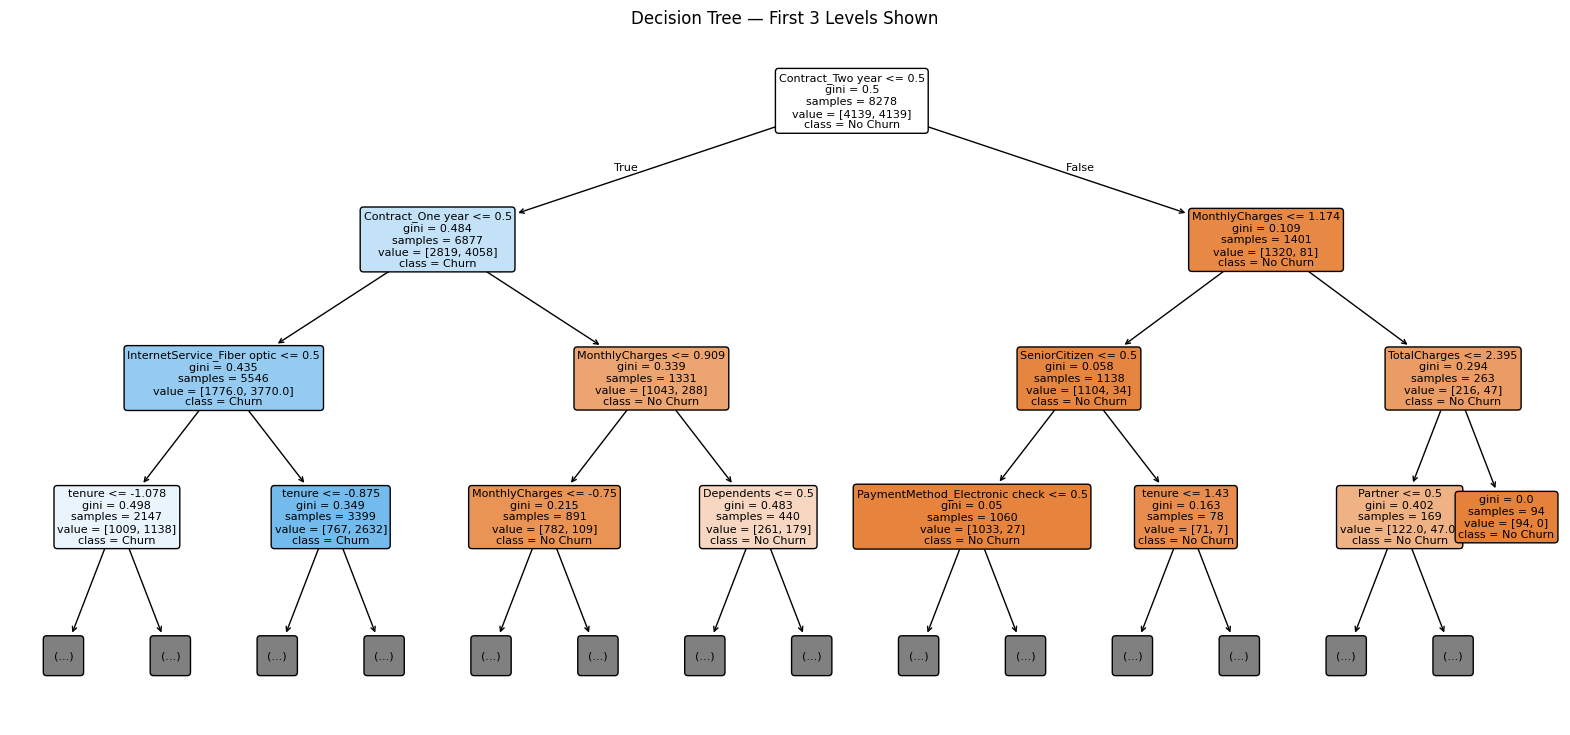

Root Split Feature: Contract_Two year


In [18]:

# 5.2 — Decision Tree Baseline

dt = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

dt.fit(X_train_smote, y_train_smote)

pred_dt = dt.predict(X_test)
prob_dt = dt.predict_proba(X_test)[:, 1]

print_metrics(y_test, pred_dt, prob_dt, "Decision Tree Baseline (max_depth=5)")

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, pred_dt),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(20, 9))
plot_tree(
    dt,
    max_depth=3,
    feature_names=feature_names,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree — First 3 Levels Shown")
plt.show()

root_index = dt.tree_.feature[0]
print("Root Split Feature:", feature_names[root_index])


Depth values: [3, 4, 5, 6, 7, 8, None]
CV F1: [np.float64(0.577), np.float64(0.6129), np.float64(0.6089), np.float64(0.6015), np.float64(0.6057), np.float64(0.6045), np.float64(0.4807)]
Best Depth: 4


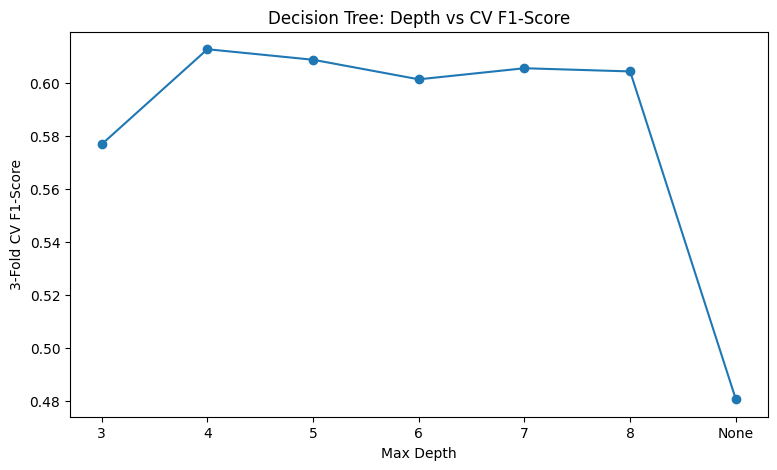


Final Decision Tree (depth=4)
Accuracy : 0.7438
Precision: 0.5113
Recall   : 0.7834
F1       : 0.6188
AUC-ROC  : 0.8153


In [20]:

# Decision Tree max_depth tuning — 3-fold CV

depths = [3, 4, 5, 6, 7, 8, None]
depth_cv_f1 = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        class_weight="balanced",
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train,   # original training data
        y_train,
        cv=cv,
        scoring="f1"
    )
    depth_cv_f1.append(scores.mean())

best_depth = depths[int(np.argmax(depth_cv_f1))]

print("Depth values:", depths)
print("CV F1:", [round(v, 4) for v in depth_cv_f1])
print("Best Depth:", best_depth)

plt.figure(figsize=(9, 5))
plt.plot(
    range(len(depths)),
    depth_cv_f1,
    marker="o"
)
plt.xticks(range(len(depths)), [str(d) for d in depths])
plt.xlabel("Max Depth")
plt.ylabel("3-Fold CV F1-Score")
plt.title("Decision Tree: Depth vs CV F1-Score")
plt.show()

best_dt = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight="balanced",
    random_state=42
)
best_dt.fit(X_train, y_train)

pred_best_dt = best_dt.predict(X_test)
prob_best_dt = best_dt.predict_proba(X_test)[:, 1]

print_metrics(y_test, pred_best_dt, prob_best_dt, f"Final Decision Tree (depth={best_depth})")


In [21]:

# 5.3 — Best Model: SMOTE vs class_weight='balanced'
# Use the highest-Recall model from the four final candidates after Step 6.
# Here we prepare a fair Decision Tree comparison as a required demonstration.

dt_smote = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)
dt_smote.fit(X_train_smote, y_train_smote)
pred_smote = dt_smote.predict(X_test)
recall_smote = recall_score(y_test, pred_smote, zero_division=0)

dt_balanced = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight="balanced",
    random_state=42
)
dt_balanced.fit(X_train, y_train)
pred_balanced = dt_balanced.predict(X_test)
recall_balanced = recall_score(y_test, pred_balanced, zero_division=0)

smote_balance_df = pd.DataFrame({
    "Method": ["SMOTE", "class_weight='balanced'"],
    "Recall": [recall_smote, recall_balanced]
})

display(smote_balance_df.round(4))

if recall_smote > recall_balanced:
    print("Better Recall: SMOTE")
elif recall_balanced > recall_smote:
    print("Better Recall: class_weight='balanced'")
else:
    print("Both methods have the same Recall.")


,Method,Recall
0,SMOTE,0.7834
1,class_weight='balanced',0.7834


Both methods have the same Recall.


# Step 6 — Model Evaluation & Comparison

In [22]:

# Four final candidate models
models = {
    "KNN": best_knn,
    "Naive Bayes": nb,
    "SVM": best_svm,
    "Decision Tree": best_dt
}

results = []
roc_data = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    start = time.perf_counter()
    model.fit(X_train_smote, y_train_smote)
    train_time = time.perf_counter() - start

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    predictions[name] = pred
    probabilities[name] = prob

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-Score": f1_score(y_test, pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_test, prob),
        "Training Time (seconds)": train_time
    })

    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_data[name] = (fpr, tpr, roc_auc_score(y_test, prob))

comparison_df = pd.DataFrame(results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("FINAL MODEL COMPARISON — SORTED BY RECALL")
display(comparison_df.round(4))

best_model_name = comparison_df.loc[0, "Model"]
best_recall = comparison_df.loc[0, "Recall"]

print(f"\nBest model by Recall: {best_model_name}")
print(f"Best Recall: {best_recall:.4f}")


FINAL MODEL COMPARISON — SORTED BY RECALL


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Training Time (seconds)
0,KNN,0.7182,0.4817,0.8075,0.6034,0.8158,0.0079
1,Naive Bayes,0.7239,0.4876,0.7914,0.6035,0.8165,0.0164
2,Decision Tree,0.7459,0.5140,0.7834,0.6208,0.8103,0.0207
3,SVM,0.7275,0.4908,0.7139,0.5817,0.7886,30.4622



Best model by Recall: KNN
Best Recall: 0.8075


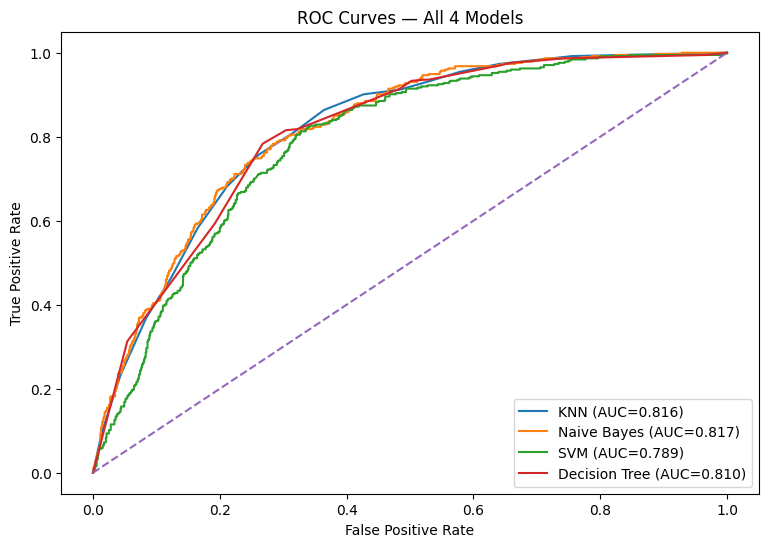

In [24]:

# 6.2 — All 4 ROC Curves

plt.figure(figsize=(9, 6))

for name, (fpr, tpr, auc_value) in roc_data.items():
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_value:.3f})"
    )

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All 4 Models")
plt.legend()
plt.show()


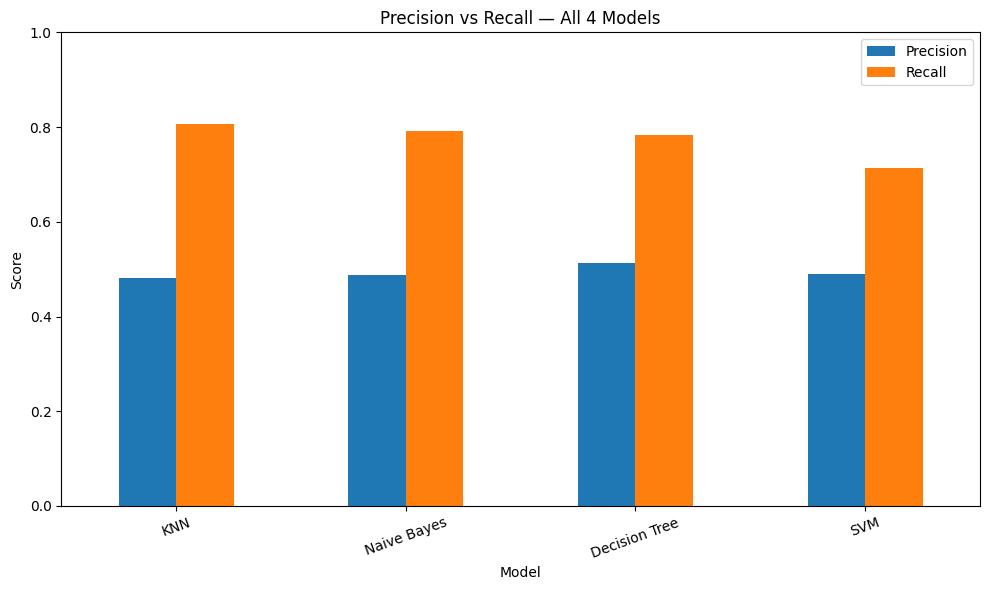

In [25]:

# 6.3 — Precision vs Recall

plot_df = comparison_df.set_index("Model")[["Precision", "Recall"]]

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)
ax.set_title("Precision vs Recall — All 4 Models")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [26]:

# 6.4 — Business Recommendation

best_row = comparison_df.iloc[0]

print("RECOMMENDATION")
print(
    f"{best_row['Model']} is the strongest candidate based on Recall, "
    f"achieving a Churn Recall of {best_row['Recall']:.3f}."
)
print(
    "Recall is the primary metric because missing a real churner (False Negative) "
    "can cause the company to lose a paying customer."
)
print(
    f"The model also has Precision={best_row['Precision']:.3f} and "
    f"AUC={best_row['AUC-ROC']:.3f}, which should be considered alongside Recall."
)
print(
    "For production, the retention team should balance Recall with Precision so "
    "limited calling capacity is not wasted on too many false alarms."
)
print(
    "If interpretability is especially important, a Decision Tree can be easier "
    "to explain than SVM, even when another model has slightly better performance."
)
print(
    f"Based on the current test results, {best_row['Model']} is the recommended "
    "starting point for the retention workflow."
)


RECOMMENDATION
KNN is the strongest candidate based on Recall, achieving a Churn Recall of 0.807.
Recall is the primary metric because missing a real churner (False Negative) can cause the company to lose a paying customer.
The model also has Precision=0.482 and AUC=0.816, which should be considered alongside Recall.
For production, the retention team should balance Recall with Precision so limited calling capacity is not wasted on too many false alarms.
If interpretability is especially important, a Decision Tree can be easier to explain than SVM, even when another model has slightly better performance.
Based on the current test results, KNN is the recommended starting point for the retention workflow.


# Step 7 — Error Analysis & Interpretation

In [27]:

# 7.1 — Error Analysis on ACTUAL best model

best_model = models[best_model_name]
best_pred = predictions[best_model_name]

# Use the original test rows for profiling.
error_profile = X_test.copy()
error_profile["Actual"] = y_test.to_numpy()
error_profile["Predicted"] = best_pred

false_negatives = error_profile[
    (error_profile["Actual"] == 1) &
    (error_profile["Predicted"] == 0)
].copy()

print("Best Model:", best_model_name)
print("False Negatives:", len(false_negatives))

if len(false_negatives) > 0:
    print("\nFalse Negative Average Tenure:",
          round(false_negatives["tenure"].mean(), 2))
    print("False Negative Average MonthlyCharges:",
          round(false_negatives["MonthlyCharges"].mean(), 2))
else:
    print("No False Negatives were found on the test set.")

# Contract profile is represented by one-hot columns after preprocessing.
contract_cols = [
    c for c in feature_names
    if c.startswith("Contract_")
]

if contract_cols and len(false_negatives) > 0:
    print("\nFalse Negative Contract Profile:")
    display(false_negatives[contract_cols].mean().round(3))

# Overall churner profile
churners = error_profile[error_profile["Actual"] == 1]

print("\nOverall Churner Profile:")
print("Average Tenure:", round(churners["tenure"].mean(), 2))
print("Average MonthlyCharges:", round(churners["MonthlyCharges"].mean(), 2))

if contract_cols:
    print("\nOverall Churner Contract Profile:")
    display(churners[contract_cols].mean().round(3))

print("\nInterpretation:")
print(
    "False Negatives are customers who actually churned but were predicted as No Churn."
)
print(
    "Comparing their tenure, MonthlyCharges and contract indicators with all churners "
    "helps identify segments that the model is missing."
)


Best Model: KNN
False Negatives: 72

False Negative Average Tenure: -0.04
False Negative Average MonthlyCharges: 0.09

False Negative Contract Profile:


Contract_One year    0.347
Contract_Two year    0.111
dtype: float64


Overall Churner Profile:
Average Tenure: -0.65
Average MonthlyCharges: 0.26

Overall Churner Contract Profile:


Contract_One year    0.096
Contract_Two year    0.024
dtype: float64


Interpretation:
False Negatives are customers who actually churned but were predicted as No Churn.
Comparing their tenure, MonthlyCharges and contract indicators with all churners helps identify segments that the model is missing.


Top 5 Decision Tree Features:


,Feature,Importance
0,Contract_Two year,0.4384
1,Contract_One year,0.3065
2,InternetService_Fiber optic,0.1044
3,tenure,0.0912
4,MonthlyCharges,0.0441


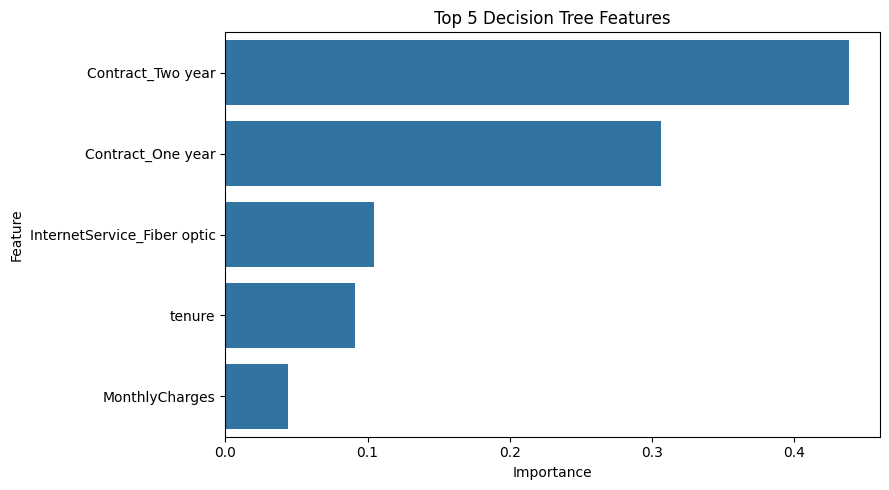


Business-Friendly Insights:
• Contract_Two year is an important predictive signal for customer churn in this Decision Tree.
• Contract_One year is an important predictive signal for customer churn in this Decision Tree.
• InternetService_Fiber optic is an important predictive signal for customer churn in this Decision Tree.
• tenure is an important predictive signal for customer churn in this Decision Tree.
• MonthlyCharges is an important predictive signal for customer churn in this Decision Tree.
• Retention teams should prioritize high-risk customers for proactive contact.
• Contract and billing-related variables can help identify vulnerable customers.
• Tenure-related information can help distinguish newer customers from loyal customers.
• The model can support targeted offers instead of contacting every customer.


In [28]:

# 7.2 — Decision Tree Feature Importance

dt_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_dt.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

top5 = dt_importance_df.head(5)

print("Top 5 Decision Tree Features:")
display(top5.round(4))

plt.figure(figsize=(9, 5))
sns.barplot(
    data=top5,
    x="Importance",
    y="Feature"
)
plt.title("Top 5 Decision Tree Features")
plt.tight_layout()
plt.show()

print("\nBusiness-Friendly Insights:")
for _, row in top5.iterrows():
    print(
        f"• {row['Feature']} is an important predictive signal "
        f"for customer churn in this Decision Tree."
    )

print("• Retention teams should prioritize high-risk customers for proactive contact.")
print("• Contract and billing-related variables can help identify vulnerable customers.")
print("• Tenure-related information can help distinguish newer customers from loyal customers.")
print("• The model can support targeted offers instead of contacting every customer.")


Top 10 SVM Permutation Features:


,Feature,Importance
0,MonthlyCharges,0.1170
1,tenure_group,0.1096
2,Contract_Two year,0.0911
3,TotalCharges,0.0688
4,tenure,0.0615
5,num_services,0.0493
6,Contract_One year,0.0473
7,AutoPay,0.0388
8,PaymentMethod_Mailed check,0.0384
9,Dependents,0.0234


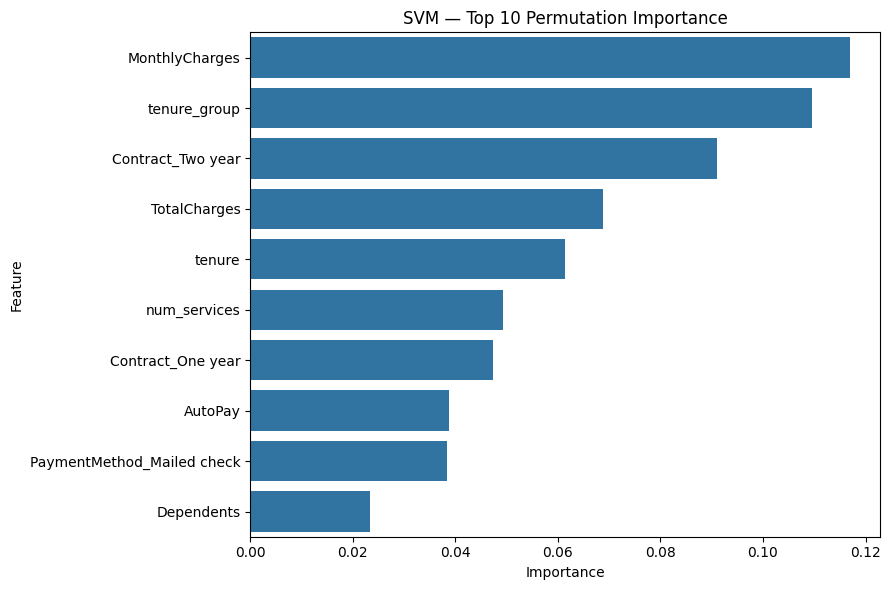

In [29]:

# Optional Bonus — SVM Permutation Importance

from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_svm,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=5,
    random_state=42
)

perm_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": perm.importances_mean
}).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

top10 = perm_df.head(10)

print("Top 10 SVM Permutation Features:")
display(top10.round(4))

plt.figure(figsize=(9, 6))
sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)
plt.title("SVM — Top 10 Permutation Importance")
plt.tight_layout()
plt.show()


# Step 8 — Final Pipeline, Model Saving & Deployment Test

**Important:** The saved pipeline contains preprocessing + model. This avoids the original notebook's problem of saving only the model.

In [30]:

# 8.1 — Build a reproducible preprocessing + model pipeline

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Build a preprocessing pipeline for the already-engineered numeric features.
# It applies median imputation + scaling to the four continuous variables.
# Other engineered numeric features pass through unchanged.

preprocessor = ColumnTransformer(
    transformers=[
        (
            "scaled_numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            scale_cols
        )
    ],
    remainder="passthrough"
)

# Select the actual best model automatically from Step 6.
final_model_template = models[best_model_name]

# IMPORTANT:
# We train the final deployment pipeline on the ORIGINAL training set.
# This keeps the saved pipeline self-contained and avoids storing SMOTE as
# a preprocessing step for real-world inference.
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", final_model_template)
])

final_pipeline.fit(X_train, y_train)

# Test final pipeline on untouched test data
final_test_pred = final_pipeline.predict(X_test)
final_test_prob = final_pipeline.predict_proba(X_test)[:, 1]

print("Final Pipeline Model:", best_model_name)
print_metrics(
    y_test,
    final_test_pred,
    final_test_prob,
    "Saved Pipeline Test Performance"
)


Final Pipeline Model: KNN

Saved Pipeline Test Performance
Accuracy : 0.7871
Precision: 0.6201
Recall   : 0.5107
F1       : 0.5601
AUC-ROC  : 0.8239


In [ ]:

# Save pipeline

MODEL_PATH = "churn_model.pkl"

joblib.dump(final_pipeline, MODEL_PATH)

print(f"Pipeline saved successfully: {MODEL_PATH}")

# Load pipeline again
loaded_pipeline = joblib.load(MODEL_PATH)

print("Pipeline loaded successfully.")
print("Pipeline steps:", loaded_pipeline.named_steps.keys())


In [ ]:

# Test loaded pipeline on 5 sample customers

sample_customers = X_test.head(5).copy()

loaded_probabilities = loaded_pipeline.predict_proba(sample_customers)[:, 1]
loaded_predictions = loaded_pipeline.predict(sample_customers)

deployment_results = pd.DataFrame({
    "Customer": [f"Customer {i}" for i in range(1, 6)],
    "Churn Probability": loaded_probabilities,
    "Prediction": np.where(
        loaded_predictions == 1,
        "Churn",
        "No Churn"
    )
})

display(deployment_results.round({"Churn Probability": 3}))

print("\nDeployment test completed successfully.")


In [ ]:

# Final submission checklist

print("========== FINAL EXAM CHECKLIST ==========")
print("✓ Step 2: Dataset loading + EDA")
print("✓ Step 3: Cleaning + feature engineering + encoding + scaling + SMOTE")
print("✓ Step 4: KNN + Naive Bayes")
print("✓ Step 5: SVM + Decision Tree + SMOTE vs class_weight")
print("✓ Step 6: 4-model comparison + ROC + Precision/Recall")
print("✓ Step 7: False Negative analysis + feature importance")
print("✓ Step 8: Preprocessor + best model Pipeline + .pkl + reload test")
print(f"✓ Best model by Recall: {best_model_name}")
print(f"✓ Saved file: {MODEL_PATH}")
print("==========================================")
